In [ ]:
from google.colab import files

uploaded = files.upload()

Saving student+performance.zip to student+performance.zip


In [ ]:
import zipfile
import os

zip_file = next(iter(uploaded))

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("student_performance")

print("Extracted files:")
print(os.listdir("student_performance"))

Extracted files:
['student.zip', '.student.zip_old']


In [ ]:
import zipfile
import os

inner_zip = "student_performance/student.zip"

with zipfile.ZipFile(inner_zip, "r") as zip_ref:
    zip_ref.extractall("student_data")

print("Dataset files:")
print(os.listdir("student_data"))

Dataset files:
['student-por.csv', 'student-mat.csv', 'student-merge.R', 'student.txt']


In [ ]:
import pandas as pd

df = pd.read_csv("student_data/student-mat.csv", sep=";")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (395, 33)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
print("Data types and missing values:")
df.info()

print("\nMissing values:")
display(df.isnull().sum())

print("\nG3 value distribution:")
display(df["G3"].value_counts().sort_index())

print("\nG3 statistics:")
display(df["G3"].describe())

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0



G3 value distribution:


,count
G3,
0,38
4,1
5,7
6,15
7,9
8,32
9,28
10,56
11,47



G3 statistics:


,G3
count,395.000000
mean,10.415190
std,4.581443
min,0.000000
25%,8.000000
50%,11.000000
75%,14.000000
max,20.000000


In [ ]:
with open("student_data/student.txt", "r", encoding="utf-8") as f:
    documentation = f.read()

print(documentation)

# Attributes for both student-mat.csv (Math course) and student-por.csv (Portuguese language course) datasets:
1 school - student's school (binary: "GP" - Gabriel Pereira or "MS" - Mousinho da Silveira)
2 sex - student's sex (binary: "F" - female or "M" - male)
3 age - student's age (numeric: from 15 to 22)
4 address - student's home address type (binary: "U" - urban or "R" - rural)
5 famsize - family size (binary: "LE3" - less or equal to 3 or "GT3" - greater than 3)
6 Pstatus - parent's cohabitation status (binary: "T" - living together or "A" - apart)
7 Medu - mother's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
8 Fedu - father's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
9 Mjob - mother's job (nominal: "teacher", "health" care related, civil "services" (e.g. administrative or police), "at_home" or 

In [ ]:
df["pass_fail"] = df["G3"].apply(
    lambda grade: "PASS" if grade >= 10 else "FAIL"
)

print("PASS/FAIL distribution:")
display(df["pass_fail"].value_counts())

print("\nPASS/FAIL percentages:")
display(df["pass_fail"].value_counts(normalize=True).mul(100).round(2))

PASS/FAIL distribution:


,count
pass_fail,
PASS,265
FAIL,130



PASS/FAIL percentages:


,proportion
pass_fail,
PASS,67.09
FAIL,32.91


In [ ]:
X = df.drop(columns=["G3", "pass_fail"])
y = df["pass_fail"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nInput features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (395, 32)
y shape: (395,)

Input features:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Target:
pass_fail


In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numerical features: 15
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Categorical features: 17
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTesting target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set:
X_train: (316, 32)
y_train: (316,)

Training target distribution:
pass_fail
PASS    212
FAIL    104
Name: count, dtype: int64
pass_fail
PASS    67.09
FAIL    32.91
Name: proportion, dtype: float64

Testing set:
X_test: (79, 32)
y_test: (79,)

Testing target distribution:
pass_fail
PASS    53
FAIL    26
Name: count, dtype: int64
pass_fail
PASS    67.09
FAIL    32.91
Name: proportion, dtype: float64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [ ]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(
    y_test, y_pred_logistic, pos_label="FAIL"
)
recall_logistic = recall_score(
    y_test, y_pred_logistic, pos_label="FAIL"
)
f1_logistic = f1_score(
    y_test, y_pred_logistic, pos_label="FAIL"
)

# Probability of FAIL
y_test_fail = (y_test == "FAIL").astype(int)

roc_auc_logistic = roc_auc_score(
    y_test_fail,
    y_prob_logistic
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy  : {accuracy_logistic:.4f}")
print(f"Precision : {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1 Score : {f1_logistic:.4f}")
print(f"ROC-AUC  : {roc_auc_logistic:.4f}")

Logistic Regression Results
---------------------------
Accuracy  : 0.8861
Precision : 0.7742
Recall   : 0.9231
F1 Score : 0.8421
ROC-AUC  : 0.0348


In [ ]:
print("Model classes:", logistic_model.classes_)

# Find the column corresponding to FAIL
fail_index = list(logistic_model.classes_).index("FAIL")

# Probability that each student will FAIL
y_prob_fail_logistic = logistic_model.predict_proba(X_test)[:, fail_index]

# Convert actual labels to binary: FAIL = 1, PASS = 0
y_test_fail = (y_test == "FAIL").astype(int)

roc_auc_logistic = roc_auc_score(
    y_test_fail,
    y_prob_fail_logistic
)

print("\nCorrected Logistic Regression ROC-AUC:")
print(f"ROC-AUC : {roc_auc_logistic:.4f}")

Model classes: ['FAIL' 'PASS']

Corrected Logistic Regression ROC-AUC:
ROC-AUC : 0.9652


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest Classifier pipeline created successfully.")

Random Forest Classifier pipeline created successfully.


In [ ]:
random_forest_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_rf = random_forest_model.predict(X_test)

fail_index_rf = list(random_forest_model.classes_).index("FAIL")
y_prob_fail_rf = random_forest_model.predict_proba(X_test)[:, fail_index_rf]

y_test_fail = (y_test == "FAIL").astype(int)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(
    y_test, y_pred_rf, pos_label="FAIL"
)
recall_rf = recall_score(
    y_test, y_pred_rf, pos_label="FAIL"
)
f1_rf = f1_score(
    y_test, y_pred_rf, pos_label="FAIL"
)
roc_auc_rf = roc_auc_score(
    y_test_fail,
    y_prob_fail_rf
)

print("Random Forest Classifier Results")
print("--------------------------------")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Random Forest Classifier Results
--------------------------------
Accuracy  : 0.8734
Precision : 0.7500
Recall   : 0.9231
F1 Score : 0.8276
ROC-AUC  : 0.9376


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            random_state=42
        ))
    ]
)

print("HistGradientBoosting Classifier pipeline created successfully.")

HistGradientBoosting Classifier pipeline created successfully.


In [ ]:
gradient_boosting_model.fit(X_train, y_train)

print("HistGradientBoosting Classifier trained successfully.")

HistGradientBoosting Classifier trained successfully.


In [ ]:
y_pred_gb = gradient_boosting_model.predict(X_test)

fail_index_gb = list(gradient_boosting_model.classes_).index("FAIL")
y_prob_fail_gb = gradient_boosting_model.predict_proba(X_test)[:, fail_index_gb]

y_test_fail = (y_test == "FAIL").astype(int)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(
    y_test, y_pred_gb, pos_label="FAIL"
)
recall_gb = recall_score(
    y_test, y_pred_gb, pos_label="FAIL"
)
f1_gb = f1_score(
    y_test, y_pred_gb, pos_label="FAIL"
)
roc_auc_gb = roc_auc_score(
    y_test_fail,
    y_prob_fail_gb
)

print("HistGradientBoosting Classifier Results")
print("----------------------------------------")
print(f"Accuracy  : {accuracy_gb:.4f}")
print(f"Precision : {precision_gb:.4f}")
print(f"Recall   : {recall_gb:.4f}")
print(f"F1 Score : {f1_gb:.4f}")
print(f"ROC-AUC  : {roc_auc_gb:.4f}")

HistGradientBoosting Classifier Results
----------------------------------------
Accuracy  : 0.8734
Precision : 0.7500
Recall   : 0.9231
F1 Score : 0.8276
ROC-AUC  : 0.9565


In [ ]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf,
        accuracy_gb
    ],
    "Precision_FAIL": [
        precision_logistic,
        precision_rf,
        precision_gb
    ],
    "Recall_FAIL": [
        recall_logistic,
        recall_rf,
        recall_gb
    ],
    "F1_FAIL": [
        f1_logistic,
        f1_rf,
        f1_gb
    ],
    "ROC_AUC": [
        roc_auc_logistic,
        roc_auc_rf,
        roc_auc_gb
    ]
})

classification_results = classification_results.sort_values(
    "F1_FAIL",
    ascending=False
).reset_index(drop=True)

display(classification_results)

,Model,Accuracy,Precision_FAIL,Recall_FAIL,F1_FAIL,ROC_AUC
0,Logistic Regression,0.886076,0.774194,0.923077,0.842105,0.965167
1,Random Forest,0.873418,0.750000,0.923077,0.827586,0.937591
2,HistGradientBoosting,0.873418,0.750000,0.923077,0.827586,0.956459


In [ ]:
best_model = logistic_model

print("Selected model: Logistic Regression")
print(f"Accuracy  : {accuracy_logistic:.4f}")
print(f"Precision : {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1 Score : {f1_logistic:.4f}")
print(f"ROC-AUC  : {roc_auc_logistic:.4f}")

Selected model: Logistic Regression
Accuracy  : 0.8861
Precision : 0.7742
Recall   : 0.9231
F1 Score : 0.8421
ROC-AUC  : 0.9652


Confusion Matrix
----------------
[[24  2]
 [ 7 46]]


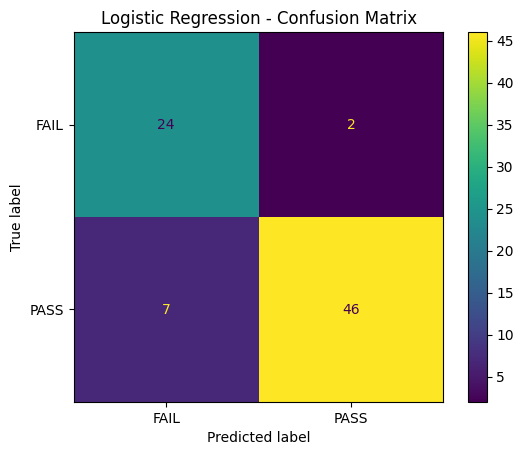

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["FAIL", "PASS"]
)

print("Confusion Matrix")
print("----------------")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAIL", "PASS"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
probability_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic,
    "Fail_Probability": y_prob_fail_logistic,
    "Pass_Probability": 1 - y_prob_fail_logistic
})

display(
    probability_comparison
    .sort_values("Fail_Probability", ascending=False)
    .head(15)
)

,Actual,Predicted,Fail_Probability,Pass_Probability
35,FAIL,FAIL,1.000000,6.871825e-11
18,FAIL,FAIL,1.000000,1.299937e-08
41,FAIL,FAIL,1.000000,6.777901e-08
28,FAIL,FAIL,0.999992,8.065469e-06
61,FAIL,FAIL,0.999980,1.963455e-05
16,FAIL,FAIL,0.999963,3.668615e-05
29,FAIL,FAIL,0.999795,2.046518e-04
73,FAIL,FAIL,0.999762,2.375567e-04
19,FAIL,FAIL,0.999680,3.199354e-04
68,FAIL,FAIL,0.999382,6.176350e-04


In [ ]:
import joblib

model_filename = "pass_fail_model.pkl"

joblib.dump(best_model, model_filename)

print(f"Model saved successfully as: {model_filename}")

Model saved successfully as: pass_fail_model.pkl


In [ ]:
import os
import joblib

print("File exists:", os.path.exists("pass_fail_model.pkl"))
print("File size:", os.path.getsize("pass_fail_model.pkl"), "bytes")

loaded_model = joblib.load("pass_fail_model.pkl")

print("Model loaded successfully.")
print("Model type:", type(loaded_model))

File exists: True
File size: 7969 bytes
Model loaded successfully.
Model type: <class 'sklearn.pipeline.Pipeline'>


In [ ]:
loaded_predictions = loaded_model.predict(X_test)

fail_index_loaded = list(loaded_model.classes_).index("FAIL")
loaded_fail_probabilities = loaded_model.predict_proba(X_test)[:, fail_index_loaded]

loaded_accuracy = accuracy_score(y_test, loaded_predictions)
loaded_precision = precision_score(
    y_test, loaded_predictions, pos_label="FAIL"
)
loaded_recall = recall_score(
    y_test, loaded_predictions, pos_label="FAIL"
)
loaded_f1 = f1_score(
    y_test, loaded_predictions, pos_label="FAIL"
)
loaded_roc_auc = roc_auc_score(
    y_test_fail,
    loaded_fail_probabilities
)

print("Reloaded Model Results")
print("----------------------")
print(f"Accuracy  : {loaded_accuracy:.4f}")
print(f"Precision : {loaded_precision:.4f}")
print(f"Recall   : {loaded_recall:.4f}")
print(f"F1 Score : {loaded_f1:.4f}")
print(f"ROC-AUC  : {loaded_roc_auc:.4f}")

Reloaded Model Results
----------------------
Accuracy  : 0.8861
Precision : 0.7742
Recall   : 0.9231
F1 Score : 0.8421
ROC-AUC  : 0.9652


In [ ]:
new_student = pd.DataFrame([{
    "school": "GP",
    "sex": "F",
    "age": 17,
    "address": "U",
    "famsize": "GT3",
    "Pstatus": "T",
    "Medu": 3,
    "Fedu": 3,
    "Mjob": "teacher",
    "Fjob": "other",
    "reason": "course",
    "guardian": "mother",
    "traveltime": 1,
    "studytime": 2,
    "failures": 0,
    "schoolsup": "no",
    "famsup": "yes",
    "paid": "no",
    "activities": "yes",
    "nursery": "yes",
    "higher": "yes",
    "internet": "yes",
    "romantic": "no",
    "famrel": 4,
    "freetime": 3,
    "goout": 3,
    "Dalc": 1,
    "Walc": 1,
    "health": 4,
    "absences": 4,
    "G1": 12,
    "G2": 13
}])

prediction = loaded_model.predict(new_student)[0]

fail_index = list(loaded_model.classes_).index("FAIL")
fail_probability = loaded_model.predict_proba(new_student)[0][fail_index]
pass_probability = 1 - fail_probability

print("Prediction:", prediction)
print(f"Pass Probability: {pass_probability:.2%}")
print(f"Fail Probability: {fail_probability:.2%}")

Prediction: PASS
Pass Probability: 99.99%
Fail Probability: 0.01%
